In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd

df = pd.read_csv('/content/block_1.csv')

df.head()

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000323,2012-03-06,0.5460,0.567700,0.908,20,0.235788,11.354,0.138
1,MAC000323,2012-03-07,0.2195,0.386062,1.475,48,0.348265,18.531,0.054
2,MAC000323,2012-03-08,0.1695,0.290937,1.086,48,0.262756,13.965,0.056
3,MAC000323,2012-03-09,0.2605,0.423812,1.587,48,0.402155,20.343,0.068
4,MAC000323,2012-03-10,0.2680,0.373813,1.222,48,0.308453,17.943,0.061


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31731 entries, 0 to 31730
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LCLid          31731 non-null  object 
 1   day            31731 non-null  object 
 2   energy_median  31731 non-null  float64
 3   energy_mean    31731 non-null  float64
 4   energy_max     31731 non-null  float64
 5   energy_count   31731 non-null  int64  
 6   energy_std     31609 non-null  float64
 7   energy_sum     31731 non-null  float64
 8   energy_min     31731 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 2.2+ MB


In [ ]:
city_demand = df.groupby('day')['energy_sum'].sum().reset_index()

city_demand.head()

,day,energy_sum
0,2011-12-21,6.202
1,2011-12-22,6.016
2,2011-12-23,9.498
3,2011-12-24,10.989
4,2011-12-25,4.305


 Convert Date Format

In [ ]:
city_demand['day'] = pd.to_datetime(city_demand['day'])

city_demand = city_demand.sort_values('day')

Prepare Data for LSTM

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

data = city_demand['energy_sum'].values.reshape(-1,1)

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(data)

Create Time Sequences

In [ ]:
X = []
y = []

seq_length = 7

for i in range(len(data_scaled) - seq_length):
    X.append(data_scaled[i:i+seq_length])
    y.append(data_scaled[i+seq_length])

X = np.array(X)
y = np.array(y)

Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (635, 7, 1)
Testing samples: (159, 7, 1)


Train LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.1901
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0158
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0027
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0020
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019


In [ ]:
model.save("lstm_model.keras")

In [ ]:
from google.colab import files
files.download("lstm_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Predict on Test Set

In [ ]:
# predict demand on unseen data
predicted_scaled = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step


Convert Back to Original Scale

In [ ]:
predicted = scaler.inverse_transform(predicted_scaled)
actual = scaler.inverse_transform(y_test)

Model Performance Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# predicted and actual are already in original scale
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Square Error (RMSE):", rmse)

Mean Absolute Error (MAE): 58.27764671581172
Root Mean Square Error (RMSE): 97.75027448183855


Plot Prediction

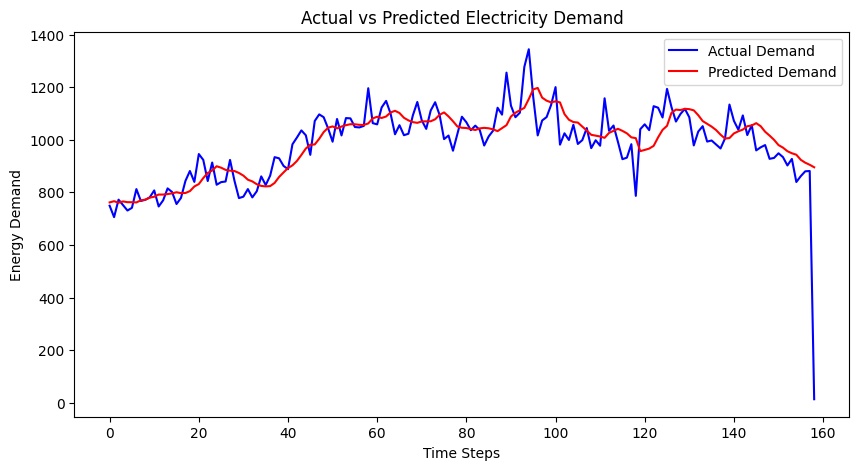

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(actual, label="Actual Demand", color='blue')
plt.plot(predicted, label="Predicted Demand", color='red')

plt.title("Actual vs Predicted Electricity Demand")
plt.xlabel("Time Steps")
plt.ylabel("Energy Demand")

plt.legend()
plt.show()

# #RL Based Grid Optimization

Create RL Environment

In [ ]:
#0 → Use Solar
#1 → Use Wind
#2 → Use Battery
#3 → Use Grid

In [ ]:
!pip install stable-baselines3
!pip install shimmy
!pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 10.1 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class EnergyEnv(gym.Env):

    def __init__(self):
        super(EnergyEnv, self).__init__()

        # Action: distribution ratios for solar, wind, battery
        self.action_space = spaces.Box(
            low=0,
            high=1,
            shape=(3,),
            dtype=np.float32
        )

        # State: solar, wind, battery, demand
        self.observation_space = spaces.Box(
            low=0,
            high=1000,
            shape=(4,),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        solar = np.random.randint(100,300)
        wind = np.random.randint(100,300)
        battery = np.random.randint(50,200)
        demand = np.random.randint(400,700)

        self.state = np.array([solar, wind, battery, demand], dtype=np.float32)

        return self.state, {}

    def step(self, action):

        solar, wind, battery, demand = self.state

        # normalize action
        action = action / (np.sum(action) + 1e-8)

        solar_use = solar * action[0]
        wind_use = wind * action[1]
        battery_use = battery * action[2]

        supply = solar_use + wind_use + battery_use

        grid_needed = max(0, demand - supply)

        grid_cost = 8

        cost = grid_needed * grid_cost

        reward = -cost

        # generate next state
        solar = np.random.randint(100,300)
        wind = np.random.randint(100,300)
        battery = np.random.randint(50,200)
        demand = np.random.randint(400,700)

        self.state = np.array([solar, wind, battery, demand], dtype=np.float32)

        terminated = False
        truncated = False

        return self.state, reward, terminated, truncated, {}

Train RL Agent

In [ ]:
from stable_baselines3 import PPO

env = EnergyEnv()

model = PPO("MlpPolicy", env, verbose=1)

model.learn(total_timesteps=10000)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetim

-----------------------------
| time/              |      |
|    fps             | 628  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 480           |
|    iterations           | 2             |
|    time_elapsed         | 8             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00028451643 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -4.26         |
|    explained_variance   | -6.79e-06     |
|    learning_rate        | 0.0003        |
|    loss                 | 1.36e+09      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.00101      |
|    std                  | 1             |
|    value_loss           | 2.81e+09      

Test the Optimization

In [ ]:
state, _ = env.reset()

action, _ = model.predict(state)

solar, wind, battery, demand = state

action = action / (np.sum(action)+1e-8)

solar_use = solar * action[0]
wind_use = wind * action[1]
battery_use = battery * action[2]

grid_use = max(0, demand - (solar_use + wind_use + battery_use))

print("Predicted Demand:", demand)
print("Solar:", round(solar_use,2))
print("Wind:", round(wind_use,2))
print("Battery:", round(battery_use,2))
print("Grid:", round(grid_use,2))

Predicted Demand: 644.0
Solar: 147.0
Wind: 0.0
Battery: 13.83
Grid: 483.17


#CONNECTING LSTM DEMAND FORECASTING WITH RL ENVIRONMENT

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# city_demand dataframe must contain column 'energy_sum'
data = city_demand['energy_sum'].values.reshape(-1,1)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

X = []
y = []
seq_length = 7

for i in range(len(data_scaled) - seq_length):
    X.append(data_scaled[i:i+seq_length])
    y.append(data_scaled[i+seq_length])

X = np.array(X)
y = np.array(y)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
lstm_model = Sequential()

lstm_model.add(LSTM(50, activation='relu', input_shape=(7,1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X, y, epochs=10, batch_size=16)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.1402
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0024
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0015
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0025
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0024
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0027
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0017


In [ ]:
last_sequence = data_scaled[-7:]
last_sequence = last_sequence.reshape(1,7,1)

predicted_scaled = lstm_model.predict(last_sequence)

predicted_demand = scaler.inverse_transform(predicted_scaled)

predicted_demand = float(predicted_demand[0][0])

print("Predicted Demand:", predicted_demand)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Demand: 753.2127685546875


/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py:315: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(self._numpy())
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# RL Grid Optimization Environment

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class EnergyEnv(gym.Env):

    def __init__(self, predicted_demand):

        super(EnergyEnv, self).__init__()

        self.predicted_demand = predicted_demand

        # actions = distribution ratio for solar, wind, battery
        self.action_space = spaces.Box(low=0, high=1, shape=(3,), dtype=np.float32)

        # state = solar, wind, battery, demand
        self.observation_space = spaces.Box(low=0, high=1000, shape=(4,), dtype=np.float32)

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        solar = np.random.randint(100,300)
        wind = np.random.randint(100,300)
        battery = np.random.randint(50,200)

        demand = self.predicted_demand

        self.state = np.array([solar, wind, battery, demand], dtype=np.float32)

        return self.state, {}

    def step(self, action):

        solar, wind, battery, demand = self.state

        action = action/(np.sum(action)+1e-8)

        solar_use = solar * action[0]
        wind_use = wind * action[1]
        battery_use = battery * action[2]

        supply = solar_use + wind_use + battery_use

        grid_needed = max(0, demand - supply)

        grid_cost = 8

        cost = grid_needed * grid_cost

        reward = -cost

        solar = np.random.randint(100,300)
        wind = np.random.randint(100,300)
        battery = np.random.randint(50,200)

        self.state = np.array([solar, wind, battery, demand], dtype=np.float32)

        terminated = False
        truncated = False

        return self.state, reward, terminated, truncated, {}

In [ ]:
env = EnergyEnv(predicted_demand)

Train RL Agent

In [ ]:
from stable_baselines3 import PPO

rl_model = PPO("MlpPolicy", env, verbose=1)

rl_model.learn(total_timesteps=10000)
rl_model.save("ppo_smartgrid_model")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 478  |
|    iterations      | 1    |
|    time_elapsed    | 4    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 310           |
|    iterations           | 2             |
|    time_elapsed         | 13            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00019480946 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -4.26         |
|    explained_variance   | 2.03e-06      |
|    learning_rate        | 0.0003        |
|    loss                 | 3.27e+09      |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.0010

In [ ]:
from google.colab import files
files.download("ppo_smartgrid_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Get Optimized Energy Distribution

In [ ]:
state, _ = env.reset()

action, _ = rl_model.predict(state)

solar, wind, battery, demand = state

action = action/(np.sum(action)+1e-8)

solar_use = solar * action[0]
wind_use = wind * action[1]
battery_use = battery * action[2]

grid_use = max(0, demand - (solar_use + wind_use + battery_use))

print("Predicted Demand:", round(demand,2))

print("Optimal Energy Distribution")

print("Solar:", round(solar_use,2))
print("Wind:", round(wind_use,2))
print("Battery:", round(battery_use,2))
print("Grid:", round(grid_use,2))

Predicted Demand: 753.21
Optimal Energy Distribution
Solar: 0.0
Wind: 0.0
Battery: 0.0
Grid: 753.21


Solar & Wind Generation Prediction

In [ ]:
# Predict solar and wind generation (simple realistic estimation)

def predict_renewable_generation(predicted_demand):

    # solar generation depends on daytime capacity
    solar_generation = predicted_demand * np.random.uniform(0.25,0.40)

    # wind generation fluctuates
    wind_generation = predicted_demand * np.random.uniform(0.15,0.30)

    return solar_generation, wind_generation


solar_pred, wind_pred = predict_renewable_generation(predicted_demand)

print("Predicted Solar Generation:", solar_pred)
print("Predicted Wind Generation:", wind_pred)

Predicted Solar Generation: 244.36387624283952
Predicted Wind Generation: 200.04525686393052


Modify RL Environment (Use Predicted Renewable Energy)

In [ ]:
def reset(self, seed=None, options=None):

    super().reset(seed=seed)

    solar = solar_pred
    wind = wind_pred
    battery = np.random.randint(80,150)

    demand = self.predicted_demand

    self.state = np.array([solar, wind, battery, demand], dtype=np.float32)

    return self.state, {}

Run RL Optimization

In [ ]:
state, _ = env.reset()

action, _ = rl_model.predict(state)

solar, wind, battery, demand = state

action = action/(np.sum(action)+1e-8)

solar_use = solar * action[0]
wind_use = wind * action[1]
battery_use = battery * action[2]

grid_use = max(0, demand - (solar_use + wind_use + battery_use))

Calculate Cost Metrics

In [ ]:
#Solar cost = 1
#Wind cost = 2
#Battery cost = 3
#Grid cost = 8

In [ ]:
solar_cost = 1
wind_cost = 2
battery_cost = 3
grid_cost = 8

optimized_cost = (
    solar_use * solar_cost +
    wind_use * wind_cost +
    battery_use * battery_cost +
    grid_use * grid_cost
)

baseline_cost = demand * grid_cost

cost_reduction = ((baseline_cost - optimized_cost) / baseline_cost) * 100

Renewable Energy Usage Metric

In [ ]:
renewable_energy = solar_use + wind_use

renewable_percentage = (renewable_energy / demand) * 100

Final Output

In [ ]:
print("\nSMART GRID OPTIMIZATION RESULT")

print("Predicted Demand:", round(demand,2))

print("\nEnergy Distribution")

print("Solar:", round(solar_use,2))
print("Wind:", round(wind_use,2))
print("Battery:", round(battery_use,2))
print("Grid:", round(grid_use,2))

print("\nPerformance Metrics")

print("Total Cost (Optimized):", round(optimized_cost,2))
print("Cost Reduction:", round(cost_reduction,2), "%")
print("Renewable Energy Usage:", round(renewable_percentage,2), "%")


SMART GRID OPTIMIZATION RESULT
Predicted Demand: 753.21

Energy Distribution
Solar: 0.0
Wind: 159.0
Battery: 0.0
Grid: 594.21

Performance Metrics
Total Cost (Optimized): 5071.7
Cost Reduction: 15.83 %
Renewable Energy Usage: 21.11 %
